# Gradient Difference

## 1. Purpose of this notebook

Gradient Ascent increases error on records that must be forgotten. Gradient Difference uses the same forget-set ascent direction while also learning from retained records, so each update tries to weaken forgotten behaviour without unnecessarily discarding useful retained behaviour.

This notebook compares that approximate update with full retraining and the established unlearning methods. It does not claim certified erasure; full retraining remains the behavioural reference.


The fixed objective is

$$
L_{\mathrm{GD}}=-L_{\mathrm{forget}}+L_{\mathrm{retain}}.
$$

The negative forget term moves the model towards higher loss on forgotten training rows. The positive retain term simultaneously moves it towards lower loss on retained training rows. This retain term is what distinguishes Gradient Difference from forget-only Gradient Ascent.


Every scenario starts from the same frozen baseline and follows five fixed epochs. Epoch 5 is the primary result: validation labels, test labels, Truth Ratio, KS results and full-retraining similarity are not used to choose a checkpoint. The implementation adapts TOFU's objective to tabular binary classification rather than reproducing its language-model experiment.


## 2. Load frozen data and reference artefacts

The setup below fixes the reproducibility settings, locates the clean submission workspace and records the method provenance before loading established evidence.


In [1]:
# Import only the libraries required by the established notebook workflow.
import copy
import hashlib
import json
import math
import random
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp


In [2]:
# Import only the libraries required by the established notebook workflow.
from sklearn.exceptions import InconsistentVersionWarning
from sklearn.metrics import (accuracy_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix, f1_score, log_loss,
    precision_score, recall_score, roc_auc_score)
from torch import nn
from torch.utils.data import DataLoader, Dataset


Paths are resolved without a machine-specific username. Existing data and reference artefacts are read only; this notebook writes only to its own Gradient Difference directories.


In [3]:
# Locate the submission root without relying on a machine-specific path.
def locate_submission_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, cwd / "final_submission", *cwd.parents]:
        if (candidate / "data/final/kidney_transplant_assessments.csv").is_file():
            return candidate
    raise FileNotFoundError("Could not locate final_submission")

ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
IDENTITY_PATH = ROOT / "data/final/kidney_transplant_identity.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
MEMBERSHIP_PATH = ROOT / "processed_data/deletion_scenario_membership.csv"
BASELINE_DIR = ROOT / "models/baseline"
FULL_DIR = ROOT / "results/full_retraining"
FINE_DIR = ROOT / "results/retain_set_fine_tuning"


In [4]:
# Fail early if this stage no longer matches the frozen experiment contract.
ASCENT_DIR = ROOT / "results/gradient_ascent"
SISA_DIR = ROOT / "results/sisa/hash_based"
MODEL_DIR = ROOT / "models/gradient_difference"
RESULT_DIR = ROOT / "results/gradient_difference"
FIGURE_DIR = RESULT_DIR / "figures"


Pre-existing submission files are fingerprinted before the experiment. The final integrity check confirms that these protected inputs remain unchanged.


In [5]:
# Fingerprint frozen inputs so presentation work cannot mask experiment changes.
excluded = ("models/gradient_difference/", "results/gradient_difference/",
            "processed_data/gradient_difference/")
protected_paths = []
for path in sorted(item for item in ROOT.rglob("*") if item.is_file()):
    relative = path.relative_to(ROOT).as_posix()
    if relative == "notebooks/06_gradient_difference.ipynb":
        continue
    if relative == "notebooks/06_gradient_difference.html":
        continue
    if relative.startswith(excluded):
        continue
    protected_paths.append(path)

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


In [6]:
# Fail early if this stage no longer matches the frozen experiment contract.

protected_hashes_before = {
    path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths
}
for path in [MODEL_DIR, RESULT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "Gradient Difference"}, indent=2) + "\n"
)


59

The seed, threshold, optimiser settings and five-epoch schedule are fixed to support a fair comparison with the established approximate-method experiments.


In [7]:
# Keep the seed, threshold and update schedule fixed across all scenarios.
SEED = 42
DEVICE = torch.device("cpu")
THRESHOLD = 0.62
SCENARIOS = ["recipient_withdrawal", "donor_withdrawal", "hospital_removal",
             "invalid_consent", "retention_expiry"]
CONFIG = {"seed": SEED, "device": str(DEVICE), "threshold": THRESHOLD,
          "epochs": 5, "batch_size": 512, "learning_rate": 1e-5,
          "weight_decay": 0.0, "gradient_clip_norm": 1.0,
          "optimizer": "AdamW", "forget_weight": -1.0, "retain_weight": 1.0}

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seed()
torch.use_deterministic_algorithms(True)


In [8]:
torch.set_num_threads(1)
display(pd.Series(CONFIG, name="value").to_frame())


,value
seed,42
device,cpu
threshold,0.62
epochs,5
batch_size,512
learning_rate,0.00001
weight_decay,0.0
gradient_clip_norm,1.0
optimizer,AdamW
forget_weight,-1.0


The provenance record separates the original Gradient Difference principle from its binary-classification adaptation.


In [9]:
# Record which TOFU principle is retained and which details are tabular adaptations.
method_provenance = {
    "paper": "TOFU: A Task of Fictitious Unlearning for LLMs",
    "paper_section": "Section 3.2, Unlearning Algorithms, Gradient Difference",
    "paper_url": "https://arxiv.org/html/2401.06121#S3.SS2",
    "official_repository": "https://github.com/locuslab/tofu",
    "files_consulted": ["forget.py", "data_module.py", "dataloader.py", "config/forget.yaml"],
    "original_objective": "-L_forget + L_retain",
    "paired_sampling": "dataset length equals forget set; each forget item pairs with one sampled retain item",
    "reproduced_exactly": ["fresh all-data model", "equal loss weights", "reverse only forget loss",
        "one combined backward pass", "one retain sample per forget sample", "five fixed epochs",
        "epoch defined by a complete forget-set pass", "epoch 5 primary", "no oracle for Gradient Difference"],
    "binary_adaptation": "token-level language-model cross-entropy is replaced by established unweighted BCEWithLogitsLoss",
    "inapplicable_llm_infrastructure": ["DeepSpeed", "BFloat16", "token masking", "causal-LM tokenisation"],
    "claim_boundary": "faithful algorithmic adaptation; not a reproduction of the TOFU LLM experiment",
}


In [10]:
(RESULT_DIR / "method_provenance.json").write_text(json.dumps(method_provenance, indent=2) + "\n")


1218

The immutable assessment data, identity records, permanent splits and approved feature contract are loaded together so that scenario construction and leakage checks use the same established inputs.


In [11]:
# Reuse the immutable data, permanent splits and approved classifier features.
assessments = pd.read_csv(DATA_PATH)
identity = pd.read_csv(IDENTITY_PATH)
splits = pd.read_csv(SPLIT_PATH)
membership = pd.read_csv(MEMBERSHIP_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text())
features = feature_contract["classifier_features"]
target = feature_contract["target"]

assert assessments.shape == (60_000, 31) and identity.shape[0] == 18_000
assert assessments["assessment_id"].is_unique and splits["recipient_id"].is_unique
assert len(features) == 18 and target == "acute_rejection_within_30_days"
assert not membership.duplicated(["scenario", "assessment_id"]).any()
split_map = splits.set_index("recipient_id")["split"]
assessments["original_split"] = assessments["recipient_id"].map(split_map)
assert assessments["original_split"].notna().all()
assert set(assessments["recipient_id"]).issubset(set(identity["entity_id"]))


In [12]:
assert set(assessments["donor_id"]).issubset(set(identity["entity_id"]))


## 3. Reconstruct deletion scenarios

Notebook 02's saved membership file is authoritative. Approximate planning counts are shown only for comparison and never redefine a forget set.


In [13]:
# Treat saved membership as authoritative rather than relying on planning estimates.
approximate_counts = {"recipient_withdrawal": 426, "donor_withdrawal": 1992,
    "hospital_removal": 4314, "invalid_consent": 4148, "retention_expiry": 6262}
authoritative_counts = (membership.loc[membership["membership_type"].eq("training_forget")]
                        .groupby("scenario").size().to_dict())
count_comparison = pd.DataFrame([{"scenario": scenario,
    "approximate_expected": approximate_counts[scenario],
    "authoritative_saved": authoritative_counts[scenario],
    "discrepancy": authoritative_counts[scenario] - approximate_counts[scenario]}
    for scenario in SCENARIOS])
assert set(authoritative_counts) == set(SCENARIOS)
display(count_comparison)


,scenario,approximate_expected,authoritative_saved,discrepancy
0,recipient_withdrawal,426,426,0
1,donor_withdrawal,1992,1992,0
2,hospital_removal,4314,4314,0
3,invalid_consent,4148,4148,0
4,retention_expiry,6262,6262,0


In [14]:
# Build forget sets and their disjoint complements within each permanent split.
scenario_frames = {}


In [15]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    part = membership.loc[membership["scenario"].eq(scenario)]
    ids = {kind: set(part.loc[part["membership_type"].eq(kind), "assessment_id"])
           for kind in ["training_forget", "deleted_validation", "deleted_test"]}
    frames = {}
    for split_name, deleted_name, retain_name in [
        ("train", "training_forget", "retained_train"),
        ("validation", "deleted_validation", "retained_validation"),
        ("test", "deleted_test", "retained_test")]:
        base = assessments.loc[assessments["original_split"].eq(split_name)].copy()
        mask = base["assessment_id"].isin(ids[deleted_name])
        frames[deleted_name] = base.loc[mask].copy()
        frames[retain_name] = base.loc[~mask].copy()
        assert set(frames[deleted_name]["assessment_id"]).isdisjoint(frames[retain_name]["assessment_id"])
    scenario_frames[scenario] = frames


Each approximate run uses the frozen baseline architecture, checkpoint and preprocessor. A fresh copy of the same baseline state is created for every scenario.


In [16]:
# Match the established baseline architecture exactly for checkpoint compatibility.
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=24, hidden_dims=(64, 32), dropout=0.10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1))

    def forward(self, inputs):
        return self.network(inputs).squeeze(1)

def load_checkpoint(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

baseline_config = json.loads((BASELINE_DIR / "model_configuration.json").read_text())


In [17]:
# Load frozen inputs so this stage reuses rather than regenerates earlier evidence.
baseline_checkpoint = load_checkpoint(BASELINE_DIR / "baseline_model.pt")
with warnings.catch_warnings(record=True) as captured_preprocessor_warnings:
    warnings.simplefilter("always", InconsistentVersionWarning)
    preprocessor = joblib.load(BASELINE_DIR / "baseline_preprocessor.joblib")
preprocessor_load_warnings = [str(item.message) for item in captured_preprocessor_warnings]
assert all(issubclass(item.category, InconsistentVersionWarning)
           for item in captured_preprocessor_warnings)


In [18]:
# Start every scenario from an independent copy of the frozen baseline state.
def fresh_baseline():
    model = BaselineMLP(baseline_checkpoint["input_dim"],
        tuple(baseline_checkpoint["hidden_dims"]), baseline_checkpoint["dropout"]).to(DEVICE)
    model.load_state_dict(copy.deepcopy(baseline_checkpoint["model_state_dict"]))
    return model

def exact_baseline_state(model):
    return all(torch.equal(model.state_dict()[name], tensor)
               for name, tensor in baseline_checkpoint["model_state_dict"].items())

baseline_model = fresh_baseline()
baseline_model.eval()
assert exact_baseline_state(baseline_model)
assert baseline_config["classifier_features"] == features
assert baseline_config["threshold"] == THRESHOLD
assert sum(parameter.numel() for parameter in baseline_model.parameters()) == 3_713


Completed full-retraining, fine-tuning, Gradient Ascent and standard SISA outputs are loaded only as evaluation references. They do not influence Gradient Difference updates.


In [19]:
# Keep comparison methods as evaluation references, not training inputs.
reference_dirs = {"full": FULL_DIR, "fine": FINE_DIR, "ascent": ASCENT_DIR, "sisa": SISA_DIR}
reference_summaries = {name: json.loads((directory / "run_summary.json").read_text())
                       for name, directory in reference_dirs.items()}
assert all(item["status"] == "completed" for item in reference_summaries.values())
full_scenario = pd.read_csv(FULL_DIR / "scenario_summary.csv")
full_training = pd.read_csv(FULL_DIR / "training_summary.csv")
full_test = pd.read_csv(FULL_DIR / "retained_test_predictions.csv")
full_forget = pd.read_csv(FULL_DIR / "forget_set_reference_predictions.csv")
full_truth = pd.read_csv(FULL_DIR / "truth_ratio_reference_values.csv")
ascent_utility = pd.read_csv(ASCENT_DIR / "utility_metrics.csv")
ascent_quality = pd.read_csv(ASCENT_DIR / "forget_quality.csv")
fine_utility = pd.read_csv(FINE_DIR / "utility_metrics.csv")
sisa_utility = pd.read_csv(SISA_DIR / "utility_metrics.csv")
sisa_quality = pd.read_csv(SISA_DIR / "forget_quality.csv")


Compatibility checks confirm the established row order, permanent split membership, feature contract and exclusion of direct identifiers before training begins.


In [20]:
# Exclude direct identity and audit fields from the classifier input contract.
direct_fields = {"assessment_id", "recipient_id", "donor_id", "hospital_id",
    "training_consent_status", "training_consent_version", "retention_expiry_date",
    "full_name", "date_of_birth", "email_address", "postcode", "hospital_number"}
compatibility = []


In [21]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    frames = scenario_frames[scenario]
    expected = full_scenario.set_index("scenario").loc[scenario]
    checks = {
        "forget count": len(frames["training_forget"]) == int(expected["training_forget_rows"]),
        "retain train count": len(frames["retained_train"]) == int(expected["retained_training_rows"]),
        "retain validation count": len(frames["retained_validation"]) == int(expected["retained_validation_rows"]),
        "retain test count": len(frames["retained_test"]) == int(expected["retained_test_rows"]),
        "forget rows are training only": frames["training_forget"]["original_split"].eq("train").all(),
        "direct fields excluded": direct_fields.isdisjoint(features),
    }
    compatibility += [{"scenario": scenario, "check": name, "pass": bool(value)}
                      for name, value in checks.items()]
compatibility = pd.DataFrame(compatibility)
assert compatibility["pass"].all()


In [22]:
display(compatibility.pivot(index="scenario", columns="check", values="pass"))


check,direct fields excluded,forget count,forget rows are training only,retain test count,retain train count,retain validation count
scenario,,,,,,
donor_withdrawal,True,True,True,True,True,True
hospital_removal,True,True,True,True,True,True
invalid_consent,True,True,True,True,True,True
recipient_withdrawal,True,True,True,True,True,True
retention_expiry,True,True,True,True,True,True


In [23]:
# Preserve reference row order and keep the permanent splits disjoint.
for scenario in SCENARIOS:
    test_ids = list(scenario_frames[scenario]["retained_test"]["assessment_id"])
    forget_ids = list(scenario_frames[scenario]["training_forget"]["assessment_id"])
    ref_test = full_test.loc[full_test["scenario"].eq(scenario), "assessment_id"].tolist()
    ref_forget = full_forget.loc[full_forget["scenario"].eq(scenario), "assessment_id"].tolist()
    assert test_ids == ref_test and forget_ids == ref_forget

split_sets = {name: set(splits.loc[splits["split"].eq(name), "recipient_id"])
              for name in ["train", "validation", "test"]}
assert split_sets["train"].isdisjoint(split_sets["validation"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["validation"].isdisjoint(split_sets["test"])
display(Markdown(f"All **{len(compatibility)}** scenario compatibility checks passed; "
                 "permanent split membership and reference row order are unchanged."))


All **30** scenario compatibility checks passed; permanent split membership and reference row order are unchanged.

## 4. Define the Gradient Difference objective

The implementation keeps the two loss terms visible: forget BCE is negated to create ascent on forgotten rows, while retain BCE remains positive to protect retained behaviour.


In [24]:
class PairedAssessmentDataset(Dataset):
    # Pair every forget row with one pre-sampled retained-training row.
    def __init__(self, forget_x, forget_y, retain_x, retain_y, retain_indices):
        assert len(forget_x) == len(retain_indices)
        self.forget_x = torch.from_numpy(forget_x)
        self.forget_y = torch.from_numpy(forget_y)
        self.retain_x = torch.from_numpy(retain_x)
        self.retain_y = torch.from_numpy(retain_y)
        self.retain_indices = np.asarray(retain_indices, dtype=np.int64)

    def __len__(self):
        return len(self.forget_x)

    def __getitem__(self, index):
        retain_index = self.retain_indices[index]
        return (self.forget_x[index], self.forget_y[index],
                self.retain_x[retain_index], self.retain_y[retain_index])


The combined loss is calculated in one backward pass as $-L_{\mathrm{forget}}+L_{\mathrm{retain}}$. Negative combined values can be valid because the objective is a difference rather than an ordinary prediction loss.


In [25]:
# Keep forget ascent and retain descent explicit in the combined objective.
def gradient_difference_terms(model, forget_x, forget_y, retain_x, retain_y, criterion):
    forget_logits = model(forget_x)
    forget_bce = criterion(forget_logits, forget_y)
    retain_logits = model(retain_x)
    retain_bce = criterion(retain_logits, retain_y)
    combined_loss = -forget_bce + retain_bce
    return forget_bce, retain_bce, combined_loss

def flatten_gradients(gradients):
    return torch.cat([gradient.reshape(-1) for gradient in gradients])


The learning rate, batch size, AdamW optimiser, weight decay and clipping norm match the established Gradient Ascent experiment. Equal coefficients are fixed; there is no scheduler, early stopping, oracle or post-result tuning.


In [26]:
# Freeze the five-epoch settings; no result-dependent tuning is performed.
EPOCHS = CONFIG["epochs"]
BATCH_SIZE = CONFIG["batch_size"]
LEARNING_RATE = CONFIG["learning_rate"]
WEIGHT_DECAY = CONFIG["weight_decay"]
GRADIENT_CLIP_NORM = CONFIG["gradient_clip_norm"]
criterion = nn.BCEWithLogitsLoss()
assert EPOCHS == 5 and LEARNING_RATE == 1e-5
assert CONFIG["forget_weight"] == -1.0 and CONFIG["retain_weight"] == 1.0


## 5. Build paired forget-retain updates

Each forget example is paired with one reproducibly sampled retained-training example. Validation and test rows are excluded from the update loader.


In [27]:
# Apply the frozen preprocessor without refitting it on a deletion scenario.
scenario_matrices = {}
for scenario, frames in scenario_frames.items():
    scenario_matrices[scenario] = {}
    for name, frame in frames.items():
        matrix = preprocessor.transform(frame[features]).astype("float32")
        labels = frame[target].to_numpy(dtype="float32")
        assert matrix.shape == (len(frame), 24) and np.isfinite(matrix).all()
        scenario_matrices[scenario][name] = (matrix, labels)


Retain sampling is performed with replacement. Each epoch therefore contains exactly one retained example for every forget example without iterating over the complete retain set.


In [28]:
# Pair each forget row with reproducibly sampled retained training data.
paired_indices = {}
sampling_audits = []


In [29]:
# Keep this training step aligned with the frozen method configuration.
for scenario_index, scenario in enumerate(SCENARIOS):
    forget_frame = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    retain_frame = scenario_frames[scenario]["retained_train"].reset_index(drop=True)
    paired_indices[scenario] = {}
    for epoch in range(1, EPOCHS + 1):
        sample_seed = SEED + 10_000 * (scenario_index + 1) + epoch
        rng = np.random.default_rng(sample_seed)
        indices = rng.integers(0, len(retain_frame), size=len(forget_frame))
        paired_indices[scenario][epoch] = indices
        sampled_ids = set(retain_frame.iloc[indices]["assessment_id"])
        sampling_audits.append({"scenario": scenario, "epoch": epoch,
            "forget_set_size": len(forget_frame), "retain_set_size": len(retain_frame),
            "forget_examples": len(forget_frame), "retain_examples_sampled": len(indices),
            "batches": math.ceil(len(forget_frame) / BATCH_SIZE), "batch_size": BATCH_SIZE,
            "sampling_with_replacement": True, "random_seed": sample_seed,
            "no_validation_or_test_sampled": True,
            "all_sampled_ids_in_authoritative_retain": sampled_ids.issubset(set(retain_frame["assessment_id"]))})


In [30]:
sampling_audit = pd.DataFrame(sampling_audits)


In [31]:
# Confirm that no validation or test row enters the paired update loader.
assert sampling_audit["all_sampled_ids_in_authoritative_retain"].all()
assert sampling_audit["no_validation_or_test_sampled"].all()
assert (sampling_audit["forget_examples"] == sampling_audit["retain_examples_sampled"]).all()
for scenario in SCENARIOS:
    report = {"scenario": scenario, "epochs": sampling_audit.loc[
        sampling_audit["scenario"].eq(scenario)].to_dict(orient="records")}
    (RESULT_DIR / f"{scenario}_paired_sampling_audit.json").write_text(
        json.dumps(report, indent=2) + "\n")
display(sampling_audit)


,scenario,epoch,forget_set_size,retain_set_size,forget_examples,retain_examples_sampled,batches,batch_size,sampling_with_replacement,random_seed,no_validation_or_test_sampled,all_sampled_ids_in_authoritative_retain
0,recipient_withdrawal,1,426,41598,426,426,1,512,True,10043,True,True
1,recipient_withdrawal,2,426,41598,426,426,1,512,True,10044,True,True
2,recipient_withdrawal,3,426,41598,426,426,1,512,True,10045,True,True
3,recipient_withdrawal,4,426,41598,426,426,1,512,True,10046,True,True
4,recipient_withdrawal,5,426,41598,426,426,1,512,True,10047,True,True
5,donor_withdrawal,1,1992,40032,1992,1992,4,512,True,20043,True,True
6,donor_withdrawal,2,1992,40032,1992,1992,4,512,True,20044,True,True
7,donor_withdrawal,3,1992,40032,1992,1992,4,512,True,20045,True,True
8,donor_withdrawal,4,1992,40032,1992,1992,4,512,True,20046,True,True
9,donor_withdrawal,5,1992,40032,1992,1992,4,512,True,20047,True,True


The sampling audit below reports the actual paired memberships and confirms that every sampled retain row belongs to the authoritative retained-training complement.


In [32]:
# Report the executed sampling audit without hard-coding its values.
display(Markdown(
    f"Across five scenarios and five epochs, **{int(sampling_audit['forget_examples'].sum()):,}** "
    "forget examples are paired with the same number of reproducibly sampled retained-training examples. "
    "No validation or test row enters an update loader."
))


Across five scenarios and five epochs, **85,710** forget examples are paired with the same number of reproducibly sampled retained-training examples. No validation or test row enters an update loader.

## 6. Verify the objective and data pairing

Independent loss, gradient-sign, initialisation and membership checks verify that the executable update matches the intended method before the experiment is run.


In [33]:
# Reproduce -forget BCE + retain BCE independently before training.
test_scenario = SCENARIOS[0]
forget_x, forget_y = scenario_matrices[test_scenario]["training_forget"]
retain_x, retain_y = scenario_matrices[test_scenario]["retained_train"]
test_model = fresh_baseline().eval()
xf = torch.from_numpy(forget_x[:17])
yf = torch.from_numpy(forget_y[:17])
xr = torch.from_numpy(retain_x[:17])
yr = torch.from_numpy(retain_y[:17])
forget_loss, retain_loss, implemented_loss = gradient_difference_terms(
    test_model, xf, yf, xr, yr, criterion)
independent_loss = -criterion(test_model(xf), yf) + criterion(test_model(xr), yr)
loss_difference = float(torch.abs(implemented_loss - independent_loss))
loss_identity_pass = loss_difference <= 1e-7
assert loss_identity_pass


/var/folders/f2/sy3606vx4jjgdl5s52mj7h1h0000gn/T/ipykernel_92854/380979149.py:13: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  loss_difference = float(torch.abs(implemented_loss - independent_loss))


The gradient identity test checks that the implemented gradient equals negative forget-loss gradients plus positive retain-loss gradients.


In [34]:
# Verify that the implemented gradients have the intended opposing signs.
gradient_model = fresh_baseline().eval()
parameters = tuple(gradient_model.parameters())
forget_value = criterion(gradient_model(xf), yf)
forget_gradient = torch.autograd.grad(forget_value, parameters)
retain_value = criterion(gradient_model(xr), yr)
retain_gradient = torch.autograd.grad(retain_value, parameters)
combined_value = -criterion(gradient_model(xf), yf) + criterion(gradient_model(xr), yr)
combined_gradient = torch.autograd.grad(combined_value, parameters)
expected_gradient = -flatten_gradients(forget_gradient) + flatten_gradients(retain_gradient)
actual_gradient = flatten_gradients(combined_gradient)
maximum_gradient_difference = float(torch.max(torch.abs(actual_gradient - expected_gradient)))
gradient_identity_pass = maximum_gradient_difference <= 1e-6
assert gradient_identity_pass


Sign ablation distinguishes Gradient Difference from both forget-only Gradient Ascent and ordinary joint training. Fresh-initialisation checks confirm that all five scenarios begin from identical frozen baseline parameters.


In [35]:
# Distinguish Gradient Difference from forget-only ascent and ordinary joint fitting.
gradient_ascent_objective = -forget_loss
gradient_difference_objective = -forget_loss + retain_loss
ordinary_joint_objective = forget_loss + retain_loss
sign_ablation_pass = bool(
    torch.allclose(gradient_difference_objective, implemented_loss, atol=1e-7, rtol=0)
    and not torch.allclose(gradient_difference_objective, ordinary_joint_objective, atol=1e-7, rtol=0)
    and torch.allclose(gradient_ascent_objective, -forget_loss, atol=0, rtol=0))
initialisation_pass = all(exact_baseline_state(fresh_baseline()) for _ in SCENARIOS)
assert sign_ablation_pass and initialisation_pass


Membership checks confirm that forget rows exactly match the authoritative training-forget set and retained rows form its disjoint training complement.


In [36]:
# Verify exact forget membership and the disjoint retained-training complement.
membership_test_rows = []
training_ids = set(assessments.loc[assessments["original_split"].eq("train"), "assessment_id"])
for scenario in SCENARIOS:
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    retain_ids = set(scenario_frames[scenario]["retained_train"]["assessment_id"])
    authoritative = set(membership.loc[(membership["scenario"].eq(scenario)) &
        (membership["membership_type"].eq("training_forget")), "assessment_id"])
    membership_test_rows.append({"scenario": scenario,
        "forget_exact": forget_ids == authoritative,
        "retain_exact_complement": retain_ids == training_ids - authoritative,
        "no_overlap": forget_ids.isdisjoint(retain_ids),
        "training_only": (forget_ids | retain_ids) == training_ids})
membership_tests = pd.DataFrame(membership_test_rows)
data_membership_pass = bool(membership_tests.drop(columns="scenario").to_numpy().all())
assert data_membership_pass


In [37]:
display(membership_tests)


,scenario,forget_exact,retain_exact_complement,no_overlap,training_only
0,recipient_withdrawal,True,True,True,True
1,donor_withdrawal,True,True,True,True
2,hospital_removal,True,True,True,True
3,invalid_consent,True,True,True,True
4,retention_expiry,True,True,True,True


These checks protect the method definition rather than judging its numerical outcome. They are retained as part of the final scientific audit.


In [38]:
# Summarise method checks from their executed verification values.
display(Markdown(
    f"Loss identity passed with absolute difference **{loss_difference:.3e}**. "
    f"Gradient identity passed with maximum absolute difference **{maximum_gradient_difference:.3e}**. "
    "Sign ablation, fresh-baseline initialisation and exact membership tests also passed."
))


Loss identity passed with absolute difference **0.000e+00**. Gradient identity passed with maximum absolute difference **0.000e+00**. Sign ablation, fresh-baseline initialisation and exact membership tests also passed.

## 7. Train the fixed five-epoch trajectory

Prediction and metric helpers use the frozen threshold and established definitions. The update function then applies the paired Gradient Difference objective for exactly five epochs per scenario.


In [39]:
# Keep prediction order stable for row-level saved-result reconciliation.
def predict_probabilities(model, matrix, batch_size=2048):
    model.eval()
    probabilities = []
    with torch.no_grad():
        for start in range(0, len(matrix), batch_size):
            batch = torch.from_numpy(matrix[start:start + batch_size]).to(DEVICE)
            probabilities.append(torch.sigmoid(model(batch)).cpu().numpy())
    return np.concatenate(probabilities)

def per_record_bce(labels, probabilities):
    probabilities = np.clip(np.asarray(probabilities, dtype=np.float64), 1e-12, 1 - 1e-12)
    labels = np.asarray(labels, dtype=np.float64)
    return -(labels * np.log(probabilities) + (1 - labels) * np.log(1 - probabilities))


In [40]:
# Keep threshold 0.62 fixed while retaining threshold-free ranking metrics.
def binary_metrics(labels, probabilities, threshold=THRESHOLD):
    prediction = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, prediction, labels=[0, 1]).ravel()
    metrics = {"n": len(labels), "positive_count": int(labels.sum()),
        "prevalence": float(labels.mean()), "threshold": threshold,
        "pr_auc": average_precision_score(labels, probabilities),
        "auroc": roc_auc_score(labels, probabilities),
        "balanced_accuracy": balanced_accuracy_score(labels, prediction),
        "f1": f1_score(labels, prediction, zero_division=0),
        "binary_cross_entropy": log_loss(labels, probabilities, labels=[0, 1]),
        "precision": precision_score(labels, prediction, zero_division=0),
        "recall": recall_score(labels, prediction, zero_division=0),
        "specificity": tn / (tn + fp), "accuracy": accuracy_score(labels, prediction),
        "positive_prediction_rate": float(prediction.mean()), "true_negative": int(tn),
        "false_positive": int(fp), "false_negative": int(fn), "true_positive": int(tp)}
    metrics["bce_quality"] = float(np.exp(-metrics["binary_cross_entropy"]))
    return metrics


In [41]:
# Evaluate utility and forgotten-record behaviour as separate quantities.
def harmonic(values, epsilon=1e-12):
    values = np.asarray(values, dtype=float)
    return float(len(values) / np.sum(1.0 / np.maximum(values, epsilon)))

def add_composite(metrics):
    metrics = dict(metrics)
    components = [metrics[name] for name in
        ["pr_auc", "auroc", "balanced_accuracy", "f1", "bce_quality"]]
    metrics["composite_model_utility"] = harmonic(components)
    return metrics

def truth_ratio(labels, probabilities, epsilon):
    p_true = np.where(labels == 1, probabilities, 1 - probabilities)
    p_incorrect = 1 - p_true
    return p_true, p_incorrect, (p_incorrect + epsilon) / (p_true + epsilon)


Each optimiser step uses one forget minibatch and its paired retain minibatch. Forget and retain losses are combined before a single backward pass and the established gradient clipping is applied.


In [42]:
# Use one combined backward pass so retain learning accompanies forget ascent.
def train_gradient_difference_epoch(model, dataset, optimizer, loader_seed):
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        generator=torch.Generator().manual_seed(loader_seed))
    totals = {"forget": 0.0, "retain": 0.0, "combined": 0.0, "rows": 0, "steps": 0}
    model.train()
    started = time.perf_counter()
    for forget_x, forget_y, retain_x, retain_y in loader:
        forget_x, forget_y = forget_x.to(DEVICE), forget_y.to(DEVICE)
        retain_x, retain_y = retain_x.to(DEVICE), retain_y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        forget_bce, retain_bce, combined = gradient_difference_terms(
            model, forget_x, forget_y, retain_x, retain_y, criterion)
        combined.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        optimizer.step()
        rows = len(forget_y)
        totals["forget"] += float(forget_bce.detach()) * rows
        totals["retain"] += float(retain_bce.detach()) * rows
        totals["combined"] += float(combined.detach()) * rows
        totals["rows"] += rows
        totals["steps"] += 1
    totals["seconds"] = time.perf_counter() - started
    return totals


Every scenario starts again from the frozen baseline, uses one persistent AdamW optimiser for five epochs and saves each epoch. Epoch 5 is primary by design; earlier results are reported but not used for model selection.


In [43]:
# Keep epoch 5 primary without selecting on test utility or KS similarity.
EPSILON = float(full_truth["epsilon"].iloc[0])
trajectory_rows, epoch_utility_rows, epoch_forgetting_rows = [], [], []
test_prediction_frames, forget_prediction_frames, truth_frames = [], [], []
initialisation_rows, update_rows, final_models = [], [], {}
scenario_runtime = {}


The scenario loop keeps training decisions separate from evaluation. Retained-test utility and forgotten-record similarity are recorded for analysis, never used to choose an epoch.


In [44]:
# Save the complete fixed trajectory for audit, not for checkpoint cherry-picking.
def save_epoch_checkpoint(model, scenario, epoch):
    checkpoint = {"model_state_dict": copy.deepcopy(model.state_dict()),
        "input_dim": 24, "hidden_dims": [64, 32], "dropout": 0.10,
        "scenario": scenario, "epoch": epoch, "threshold": THRESHOLD, "seed": SEED}
    scenario_dir = MODEL_DIR / scenario
    scenario_dir.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, scenario_dir / f"epoch_{epoch}.pt")


In [45]:
# Evaluate held-out retained rows without feeding their labels into updates.
def record_utility_epoch(model, scenario, epoch, test_x, test_y, test_frame):
    probability = predict_probabilities(model, test_x).astype(np.float64)
    metrics = add_composite(binary_metrics(test_y.astype(int), probability))
    epoch_utility_rows.append({"scenario": scenario, "epoch": epoch,
                               "model": "gradient_difference", **metrics})
    test_prediction_frames.append(pd.DataFrame({"scenario": scenario, "epoch": epoch,
        "assessment_id": test_frame["assessment_id"], "true_target": test_y.astype(int),
        "gradient_difference_probability": probability,
        "gradient_difference_prediction": (probability >= THRESHOLD).astype(int)}))


In [46]:
# Compare forgotten-record behaviour with full retraining only after updating.
def record_forgetting_epoch(model, scenario, epoch, forget_x, forget_y, forget_frame, full_ratio):
    probability = predict_probabilities(model, forget_x).astype(np.float64)
    p_true, p_incorrect, ratio = truth_ratio(forget_y.astype(int), probability, EPSILON)
    ks = ks_2samp(ratio, full_ratio, alternative="two-sided", method="auto")
    epoch_forgetting_rows.append({"scenario": scenario, "epoch": epoch,
        "forget_rows": len(ratio), "gradient_difference_truth_ratio_mean": float(ratio.mean()),
        "gradient_difference_truth_ratio_median": float(np.median(ratio)),
        "full_retraining_truth_ratio_mean": float(full_ratio.mean()),
        "full_retraining_truth_ratio_median": float(np.median(full_ratio)),
        "ks_statistic": float(ks.statistic), "ks_p_value": float(ks.pvalue)})
    reference = full_forget.loc[full_forget["scenario"].eq(scenario)].reset_index(drop=True)
    forget_prediction_frames.append(pd.DataFrame({"scenario": scenario, "epoch": epoch,
        "assessment_id": forget_frame["assessment_id"], "true_target": forget_y.astype(int),
        "gradient_difference_probability": probability,
        "gradient_difference_prediction": (probability >= THRESHOLD).astype(int),
        "gradient_difference_per_record_bce": per_record_bce(forget_y, probability),
        "full_retraining_probability": reference["full_retraining_probability"].to_numpy()}))
    truth_frames.append(pd.DataFrame({"scenario": scenario, "epoch": epoch,
        "assessment_id": forget_frame["assessment_id"], "model": "gradient_difference",
        "true_target": forget_y.astype(int), "p_true": p_true, "p_incorrect": p_incorrect,
        "truth_ratio": ratio, "epsilon": EPSILON}))
    truth_frames.append(pd.DataFrame({"scenario": scenario, "epoch": epoch,
        "assessment_id": forget_frame["assessment_id"], "model": "full_retraining",
        "true_target": forget_y.astype(int), "p_true": np.nan, "p_incorrect": np.nan,
        "truth_ratio": full_ratio, "epsilon": EPSILON}))


In [47]:
# Preserve the exact epoch-5 checkpoint and account for every optimiser step.
def finish_scenario(scenario, model, forget_x, retain_x, total_seconds, total_steps):
    scenario_runtime[scenario] = total_seconds
    final_models[scenario] = model
    final_checkpoint = load_checkpoint(MODEL_DIR / scenario / f"epoch_{EPOCHS}.pt")
    torch.save(final_checkpoint, MODEL_DIR / scenario / "final_epoch_5.pt")
    expected_steps = EPOCHS * math.ceil(len(forget_x) / BATCH_SIZE)
    update_rows.append({"scenario": scenario, "epochs": EPOCHS,
        "forget_examples_processed": EPOCHS * len(forget_x),
        "retain_examples_sampled": EPOCHS * len(forget_x),
        "expected_optimizer_steps": expected_steps, "actual_optimizer_steps": total_steps,
        "combined_backward_passes": total_steps, "update_seconds": total_seconds})
    configuration = {**CONFIG, "scenario": scenario, "primary_epoch": EPOCHS,
        "baseline_source": "models/baseline/baseline_model.pt",
        "preprocessor_source": "models/baseline/baseline_preprocessor.joblib",
        "classifier_features": features, "architecture": [24, 64, 32, 1],
        "parameter_count": 3713, "training_forget_rows": len(forget_x),
        "retained_training_rows": len(retain_x)}
    (MODEL_DIR / scenario / "configuration.json").write_text(
        json.dumps(configuration, indent=2) + "\n")


In [48]:
# Reset to the frozen baseline before each scenario's five fixed epochs.
for scenario_index, scenario in enumerate(SCENARIOS):
    reset_seed(SEED + scenario_index)
    model = fresh_baseline()
    initialisation_rows.append({"scenario": scenario,
                                "exact_baseline_parameters": exact_baseline_state(model)})
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    forget_x, forget_y = scenario_matrices[scenario]["training_forget"]
    retain_x, retain_y = scenario_matrices[scenario]["retained_train"]
    test_x, test_y = scenario_matrices[scenario]["retained_test"]
    test_frame = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    forget_frame = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    full_ratio = full_truth.loc[full_truth["scenario"].eq(scenario)].set_index("assessment_id").loc[
        forget_frame["assessment_id"], "full_retraining_truth_ratio"].to_numpy(dtype=np.float64)
    total_seconds = 0.0
    total_steps = 0
    for epoch in range(1, EPOCHS + 1):
        dataset = PairedAssessmentDataset(forget_x, forget_y, retain_x, retain_y,
                                          paired_indices[scenario][epoch])
        loader_seed = SEED + 20_000 * (scenario_index + 1) + epoch
        totals = train_gradient_difference_epoch(model, dataset, optimizer, loader_seed)
        total_seconds += totals["seconds"]
        total_steps += totals["steps"]
        save_epoch_checkpoint(model, scenario, epoch)
        trajectory_rows.append({"scenario": scenario, "epoch": epoch,
            "mean_forget_bce": totals["forget"] / totals["rows"],
            "mean_retain_bce": totals["retain"] / totals["rows"],
            "mean_combined_objective": totals["combined"] / totals["rows"],
            "forget_examples": totals["rows"], "sampled_retain_examples": totals["rows"],
            "optimizer_steps": totals["steps"], "backward_passes": totals["steps"],
            "update_seconds": totals["seconds"], "primary_checkpoint": epoch == EPOCHS})
        record_utility_epoch(model, scenario, epoch, test_x, test_y, test_frame)
        record_forgetting_epoch(model, scenario, epoch, forget_x, forget_y, forget_frame, full_ratio)
    finish_scenario(scenario, model, forget_x, retain_x, total_seconds, total_steps)


Update accounting verifies the expected number of forget examples, sampled retain examples, optimiser steps and combined backward passes.


In [49]:
# Reconcile paired examples, optimiser steps and combined backward passes.
training_trajectory = pd.DataFrame(trajectory_rows)
update_accounting = pd.DataFrame(update_rows)
model_initialisation = pd.DataFrame(initialisation_rows)
assert model_initialisation["exact_baseline_parameters"].all()
assert (update_accounting["epochs"] == EPOCHS).all()
assert (update_accounting["forget_examples_processed"] == update_accounting["retain_examples_sampled"]).all()
assert (update_accounting["expected_optimizer_steps"] == update_accounting["actual_optimizer_steps"]).all()
assert (update_accounting["actual_optimizer_steps"] == update_accounting["combined_backward_passes"]).all()
display(update_accounting)


,scenario,epochs,forget_examples_processed,retain_examples_sampled,expected_optimizer_steps,actual_optimizer_steps,combined_backward_passes,update_seconds
0,recipient_withdrawal,5,2130,2130,5,5,5,0.018912
1,donor_withdrawal,5,9960,9960,20,20,20,0.059612
2,hospital_removal,5,21570,21570,45,45,45,0.124653
3,invalid_consent,5,20740,20740,45,45,45,0.124254
4,retention_expiry,5,31310,31310,65,65,65,0.253789


The loss trajectories show how the forget and retain terms developed across the fixed schedule. Because the objective is a difference, its absolute value should be read alongside both component losses.


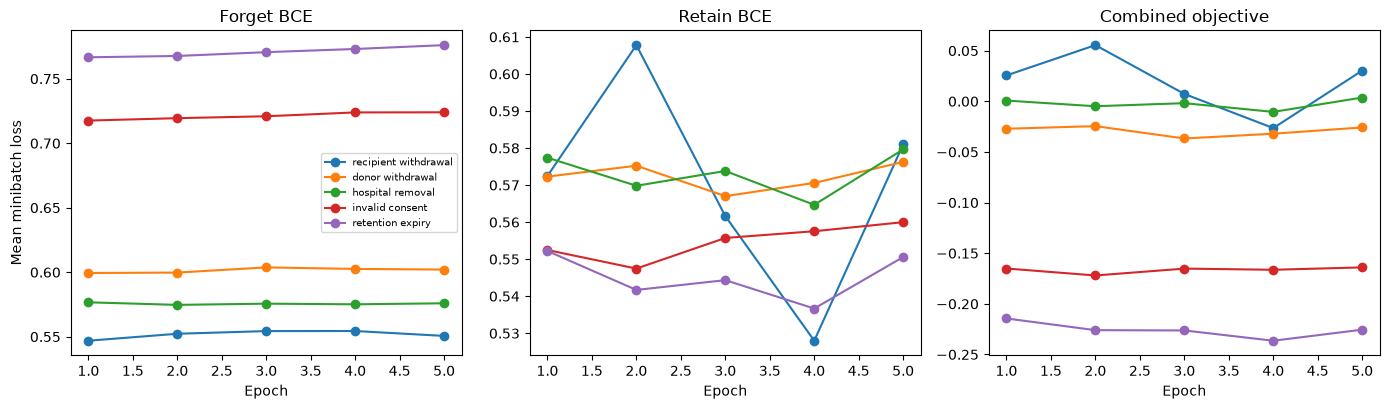

All five scenarios completed exactly **5 epochs** and **180 combined updates**.

In [50]:
# Plot both loss terms so the difference objective is not interpreted in isolation.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for scenario in SCENARIOS:
    part = training_trajectory.loc[training_trajectory["scenario"].eq(scenario)]
    for axis, column, title in zip(axes,
        ["mean_forget_bce", "mean_retain_bce", "mean_combined_objective"],
        ["Forget BCE", "Retain BCE", "Combined objective"]):
        axis.plot(part["epoch"], part[column], marker="o", label=scenario.replace("_", " "))
        axis.set(title=title, xlabel="Epoch")
axes[0].set_ylabel("Mean minibatch loss")
axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "loss_trajectory.png", dpi=160, bbox_inches="tight")
plt.show()
display(Markdown(f"All five scenarios completed exactly **{EPOCHS} epochs** and "
                 f"**{int(update_accounting['actual_optimizer_steps'].sum())} combined updates**."))


## 8. Evaluate retained-data utility and compare methods

Epoch-5 retained-test metrics are the primary utility results. Utility is evaluated separately from forgetting: preserving predictive performance does not by itself demonstrate successful unlearning.


In [51]:
# Use epoch 5 for the primary retained-data utility table.
epoch_utility = pd.DataFrame(epoch_utility_rows)
retained_test_predictions = pd.concat(test_prediction_frames, ignore_index=True)
utility_by_scenario = epoch_utility.loc[epoch_utility["epoch"].eq(EPOCHS)].reset_index(drop=True)
display(utility_by_scenario[["scenario", "pr_auc", "auroc", "balanced_accuracy", "f1",
                             "binary_cross_entropy", "composite_model_utility"]])


,scenario,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,composite_model_utility
0,recipient_withdrawal,0.169246,0.731510,0.630599,0.244503,0.574444,0.339502
1,donor_withdrawal,0.168774,0.731788,0.630699,0.243969,0.574826,0.338918
2,hospital_removal,0.173602,0.739229,0.636522,0.251788,0.573431,0.346499
3,invalid_consent,0.164194,0.735138,0.632412,0.237911,0.565358,0.333439
4,retention_expiry,0.167570,0.744588,0.639464,0.254085,0.548376,0.343864


The same retained-test basis is used to compare Gradient Difference with the baseline, full retraining, retain-set fine-tuning, Gradient Ascent and standard SISA.


In [52]:
# Compare methods on the same established retained-test basis.
comparison_rows = []


In [53]:
# Keep this stage separate so its inputs and checks remain easy to audit.
for scenario in SCENARIOS:
    for method in ["baseline", "full_retraining", "fine_tuning", "gradient_ascent"]:
        row = ascent_utility.loc[(ascent_utility["scenario"].eq(scenario)) &
                                 (ascent_utility["model"].eq(method))].iloc[0]
        comparison_rows.append({"scenario": scenario, "method": method,
            "composite_model_utility": row["composite_model_utility"],
            "pr_auc": row["pr_auc"], "auroc": row["auroc"], "f1": row["f1"]})
    row = sisa_utility.loc[(sisa_utility["scenario"].eq(scenario)) &
                           (sisa_utility["model"].eq("updated_sisa"))].iloc[0]
    comparison_rows.append({"scenario": scenario, "method": "standard_sisa",
        "composite_model_utility": row["composite_model_utility"],
        "pr_auc": row["pr_auc"], "auroc": row["auroc"], "f1": row["f1"]})
    row = utility_by_scenario.set_index("scenario").loc[scenario]
    comparison_rows.append({"scenario": scenario, "method": "gradient_difference",
        "composite_model_utility": row["composite_model_utility"],
        "pr_auc": row["pr_auc"], "auroc": row["auroc"], "f1": row["f1"]})


In [54]:
method_comparison = pd.DataFrame(comparison_rows)
display(method_comparison.pivot(index="scenario", columns="method", values="composite_model_utility"))


method,baseline,fine_tuning,full_retraining,gradient_ascent,gradient_difference,standard_sisa
scenario,,,,,,
donor_withdrawal,0.338853,0.339172,0.338987,0.338420,0.338918,0.327993
hospital_removal,0.346601,0.345881,0.347360,0.342550,0.346499,0.332814
invalid_consent,0.332878,0.332281,0.331853,0.330041,0.333439,0.317833
recipient_withdrawal,0.339417,0.339028,0.340965,0.338700,0.339502,0.331071
retention_expiry,0.343208,0.334213,0.326582,0.337672,0.343864,0.325463


Composite utility summarises retained-test performance using the established definition. The accompanying component metrics remain available so that the composite score does not replace the underlying results.


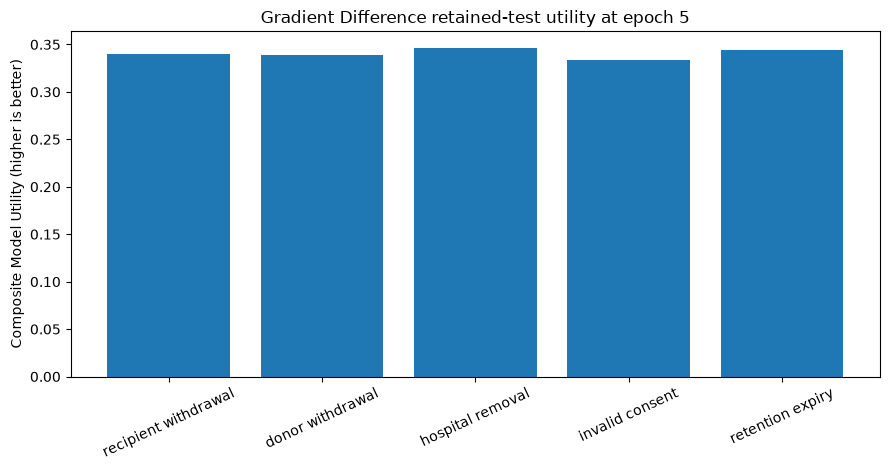

Mean epoch-5 Composite Model Utility is **0.340444**, compared with **0.337477** for plain Gradient Ascent.

In [55]:
# Keep component metrics available alongside the composite utility summary.
fig, ax = plt.subplots(figsize=(9, 4.8))
plot_data = utility_by_scenario.copy()
ax.bar(plot_data["scenario"].str.replace("_", " "), plot_data["composite_model_utility"])
ax.set(title="Gradient Difference retained-test utility at epoch 5",
       ylabel="Composite Model Utility (higher is better)")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "composite_utility.png", dpi=160, bbox_inches="tight")
plt.show()
mean_utility = float(utility_by_scenario["composite_model_utility"].mean())
ga_mean = float(method_comparison.loc[method_comparison["method"].eq("gradient_ascent"),
                                      "composite_model_utility"].mean())
display(Markdown(f"Mean epoch-5 Composite Model Utility is **{mean_utility:.6f}**, "
                 f"compared with **{ga_mean:.6f}** for plain Gradient Ascent."))


## 9. Evaluate forgetting and efficiency

Truth Ratio on forgotten training rows is compared with the full-retraining reference using the two-sample KS statistic. A lower KS statistic means closer observed distributions; neither the statistic nor its sample-size-sensitive p-value proves exact erasure.


In [56]:
# Use full retraining as the behavioural reference for forgotten rows.
epoch_forgetting = pd.DataFrame(epoch_forgetting_rows)
forget_set_predictions = pd.concat(forget_prediction_frames, ignore_index=True)
truth_ratio_values = pd.concat(truth_frames, ignore_index=True)
forgetting_by_scenario = epoch_forgetting.loc[epoch_forgetting["epoch"].eq(EPOCHS)].reset_index(drop=True)
display(forgetting_by_scenario)


,scenario,epoch,forget_rows,gradient_difference_truth_ratio_mean,gradient_difference_truth_ratio_median,full_retraining_truth_ratio_mean,full_retraining_truth_ratio_median,ks_statistic,ks_p_value
0,recipient_withdrawal,5,426,0.884480,0.792278,0.951461,0.842090,0.058685,0.455963
1,donor_withdrawal,5,1992,0.982714,0.908228,1.065314,0.963850,0.059237,0.001838
2,hospital_removal,5,4314,0.936989,0.811082,1.011090,0.882400,0.049142,0.000060
3,invalid_consent,5,4148,1.170705,0.999774,1.261086,1.043372,0.041948,0.001351
4,retention_expiry,5,6262,1.321707,1.077247,1.442658,1.148926,0.045672,0.000004


The KS results are kept alongside utility because behavioural similarity to full retraining and retained predictive performance answer different questions.


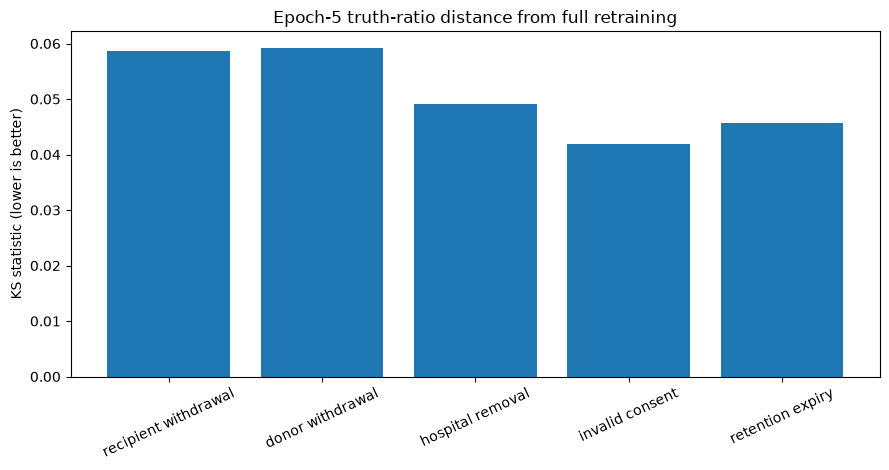

Mean epoch-5 KS statistic is **0.050937**. P-values are reported per scenario as supporting evidence; they do not prove equivalence or complete erasure.

In [57]:
# Keep the KS statistic beside its sample-size-sensitive p-value.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(forgetting_by_scenario["scenario"].str.replace("_", " "),
       forgetting_by_scenario["ks_statistic"])
ax.set(title="Epoch-5 truth-ratio distance from full retraining",
       ylabel="KS statistic (lower is better)")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ks_statistic.png", dpi=160, bbox_inches="tight")
plt.show()
mean_ks = float(forgetting_by_scenario["ks_statistic"].mean())
display(Markdown(f"Mean epoch-5 KS statistic is **{mean_ks:.6f}**. P-values are reported "
                 "per scenario as supporting evidence; they do not prove equivalence or complete erasure."))


Runtime compares Gradient Difference update time with full retraining time on this execution environment. It is a practical measurement rather than a hardware-independent property of the method.


In [58]:
# Treat wall-clock speed-up as environment-specific descriptive evidence.
efficiency_by_scenario = update_accounting[["scenario", "update_seconds"]].merge(
    full_training[["scenario", "training_seconds"]], on="scenario")
efficiency_by_scenario = efficiency_by_scenario.rename(
    columns={"update_seconds": "gradient_difference_seconds",
             "training_seconds": "full_retraining_seconds"})
efficiency_by_scenario["speed_up_vs_full_retraining"] = (
    efficiency_by_scenario["full_retraining_seconds"] /
    efficiency_by_scenario["gradient_difference_seconds"])
efficiency_by_scenario["time_reduction_pct"] = 100 * (
    efficiency_by_scenario["full_retraining_seconds"] -
    efficiency_by_scenario["gradient_difference_seconds"]) / (
    efficiency_by_scenario["full_retraining_seconds"])
display(efficiency_by_scenario)


,scenario,gradient_difference_seconds,full_retraining_seconds,speed_up_vs_full_retraining,time_reduction_pct
0,recipient_withdrawal,0.018912,3.923029,207.433632,99.517918
1,donor_withdrawal,0.059612,3.450068,57.875393,98.272150
2,hospital_removal,0.124653,3.847863,30.868513,96.760453
3,invalid_consent,0.124254,3.528170,28.394788,96.478227
4,retention_expiry,0.253789,3.111061,12.258469,91.842375


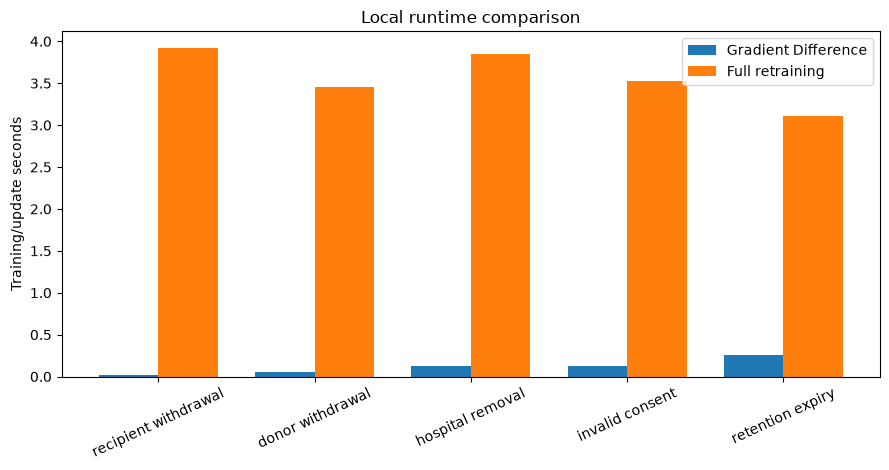

In [59]:
# Plot measured update time without using runtime for model selection.
fig, ax = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(SCENARIOS))
width = 0.38
ax.bar(x - width/2, efficiency_by_scenario["gradient_difference_seconds"], width,
       label="Gradient Difference")
ax.bar(x + width/2, efficiency_by_scenario["full_retraining_seconds"], width,
       label="Full retraining")
ax.set(xticks=x, xticklabels=[item.replace("_", " ") for item in SCENARIOS],
       ylabel="Training/update seconds", title="Local runtime comparison")
ax.tick_params(axis="x", rotation=25)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "runtime_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The trade-off view places retained utility and forgotten-record KS distance on separate axes. It is descriptive and is not used to select a checkpoint.


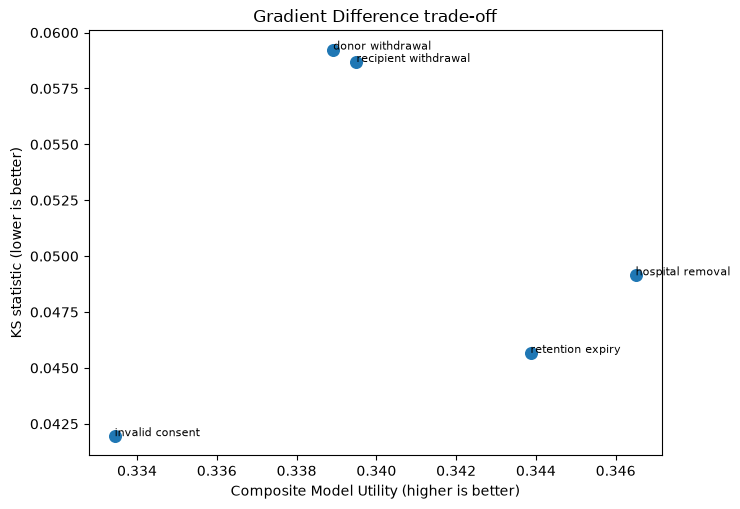

In [60]:
# Show utility and forgetting separately rather than collapsing them into one score.
tradeoff = utility_by_scenario[["scenario", "composite_model_utility"]].merge(
    forgetting_by_scenario[["scenario", "ks_statistic"]], on="scenario")
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.scatter(tradeoff["composite_model_utility"], tradeoff["ks_statistic"], s=70)
for row in tradeoff.itertuples():
    ax.annotate(row.scenario.replace("_", " "),
                (row.composite_model_utility, row.ks_statistic), fontsize=8)
ax.set(xlabel="Composite Model Utility (higher is better)",
       ylabel="KS statistic (lower is better)", title="Gradient Difference trade-off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "utility_vs_forgetting.png", dpi=160, bbox_inches="tight")
plt.show()


The generated findings below report the executed runtime and cross-method values directly from the result tables, avoiding a stale manual transcription.


In [61]:
# Generate numerical findings from the executed tables to avoid stale values.
mean_speedup = float(efficiency_by_scenario["speed_up_vs_full_retraining"].mean())
runtime_lines = [f"- **{row.scenario.replace('_', ' ').capitalize()}**: "
    f"{row.gradient_difference_seconds:.3f}s, {row.speed_up_vs_full_retraining:.2f}× versus full retraining."
    for row in efficiency_by_scenario.itertuples()]
display(Markdown("\n".join(runtime_lines) +
    f"\n\nThe unweighted mean speed-up is **{mean_speedup:.2f}×**. "
    "Runtime is hardware-dependent and remains separate from utility and forgetting."))


- **Recipient withdrawal**: 0.019s, 207.43× versus full retraining.
- **Donor withdrawal**: 0.060s, 57.88× versus full retraining.
- **Hospital removal**: 0.125s, 30.87× versus full retraining.
- **Invalid consent**: 0.124s, 28.39× versus full retraining.
- **Retention expiry**: 0.254s, 12.26× versus full retraining.

The unweighted mean speed-up is **67.37×**. Runtime is hardware-dependent and remains separate from utility and forgetting.

## 10. Verify implementation and saved artefacts

The final audit saves the established result tables, reloads every epoch-5 model and the frozen preprocessor, and independently reproduces probabilities, utility metrics, Truth Ratios and KS results.


In [62]:
# Preserve row-level and summary outputs for later cross-method analysis.
outputs = {"training_trajectory.csv": training_trajectory,
    "paired_sampling_summary.csv": sampling_audit,
    "update_accounting.csv": update_accounting,
    "model_initialisation.csv": model_initialisation,
    "epoch_utility.csv": epoch_utility,
    "utility_by_scenario.csv": utility_by_scenario,
    "retained_test_predictions.csv": retained_test_predictions,
    "epoch_forgetting.csv": epoch_forgetting,
    "forgetting_by_scenario.csv": forgetting_by_scenario,
    "forget_set_predictions.csv": forget_set_predictions,
    "truth_ratio_values.csv": truth_ratio_values,
    "efficiency_by_scenario.csv": efficiency_by_scenario,
    "method_comparison.csv": method_comparison,
    "count_comparison.csv": count_comparison}


In [63]:
for name, frame in outputs.items():
    frame.to_csv(RESULT_DIR / name, index=False, float_format="%.17g")


Reload checks confirm that the saved models and preprocessor reproduce both retained-test and forget-set probabilities within the established numerical tolerances.


In [64]:
# Reload every saved model to reproduce retained-test and forget-set probabilities.
reload_rows = []
with warnings.catch_warnings(record=True) as captured_reload_warnings:
    warnings.simplefilter("always", InconsistentVersionWarning)
    reloaded_preprocessor = joblib.load(BASELINE_DIR / "baseline_preprocessor.joblib")
assert all(issubclass(item.category, InconsistentVersionWarning)
           for item in captured_reload_warnings)


In [65]:
# Keep this training step aligned with the frozen method configuration.
for scenario in SCENARIOS:
    checkpoint = load_checkpoint(MODEL_DIR / scenario / "final_epoch_5.pt")
    model = BaselineMLP(checkpoint["input_dim"], tuple(checkpoint["hidden_dims"]), checkpoint["dropout"])
    model.load_state_dict(checkpoint["model_state_dict"])
    test_frame = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    forget_frame = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    test_x = reloaded_preprocessor.transform(test_frame[features]).astype("float32")
    forget_x = reloaded_preprocessor.transform(forget_frame[features]).astype("float32")
    test_probability = predict_probabilities(model, test_x).astype(np.float64)
    forget_probability = predict_probabilities(model, forget_x).astype(np.float64)
    saved_test = retained_test_predictions.loc[(retained_test_predictions["scenario"].eq(scenario)) &
        retained_test_predictions["epoch"].eq(EPOCHS), "gradient_difference_probability"].to_numpy()
    saved_forget = forget_set_predictions.loc[(forget_set_predictions["scenario"].eq(scenario)) &
        forget_set_predictions["epoch"].eq(EPOCHS), "gradient_difference_probability"].to_numpy()
    reload_rows.append({"scenario": scenario,
        "retained_test_max_abs_difference": float(np.max(np.abs(test_probability - saved_test))),
        "forget_set_max_abs_difference": float(np.max(np.abs(forget_probability - saved_forget))),
        "retained_test_pass": np.allclose(test_probability, saved_test, atol=1e-7, rtol=1e-7),
        "forget_set_pass": np.allclose(forget_probability, saved_forget, atol=1e-7, rtol=1e-7)})


In [66]:
model_reload_report = pd.DataFrame(reload_rows)
assert model_reload_report[["retained_test_pass", "forget_set_pass"]].to_numpy().all()


Utility metrics are recalculated from persisted predictions rather than trusted only from the in-memory tables.


In [67]:
# Recalculate utility from persisted predictions as an independent readback check.
saved_predictions = pd.read_csv(RESULT_DIR / "retained_test_predictions.csv")
saved_utility = pd.read_csv(RESULT_DIR / "utility_by_scenario.csv").set_index("scenario")
metric_reproduction_rows = []
for scenario in SCENARIOS:
    part = saved_predictions.loc[(saved_predictions["scenario"].eq(scenario)) &
                                  saved_predictions["epoch"].eq(EPOCHS)]
    recalculated = add_composite(binary_metrics(part["true_target"].to_numpy(),
        part["gradient_difference_probability"].to_numpy(dtype=np.float64)))
    for metric in ["pr_auc", "auroc", "balanced_accuracy", "f1",
                   "binary_cross_entropy", "bce_quality", "composite_model_utility"]:
        difference = abs(float(saved_utility.loc[scenario, metric]) - float(recalculated[metric]))
        metric_reproduction_rows.append({"scenario": scenario, "metric": metric,
            "absolute_difference": difference, "tolerance": 1e-8, "pass": difference <= 1e-8})
metric_reproduction = pd.DataFrame(metric_reproduction_rows)
assert metric_reproduction["pass"].all()


Truth Ratios and KS results are likewise rebuilt from saved row-level values to verify the forgetting analysis.


In [68]:
# Rebuild Truth Ratios and KS results from saved row-level values.
saved_truth = pd.read_csv(RESULT_DIR / "truth_ratio_values.csv")
saved_forgetting = pd.read_csv(RESULT_DIR / "forgetting_by_scenario.csv").set_index("scenario")
truth_reproduction_rows = []
for scenario in SCENARIOS:
    part = saved_truth.loc[(saved_truth["scenario"].eq(scenario)) & saved_truth["epoch"].eq(EPOCHS)]
    gd = part.loc[part["model"].eq("gradient_difference")]
    reproduced = (gd["p_incorrect"] + gd["epsilon"]) / (gd["p_true"] + gd["epsilon"])
    ratio_pass = np.allclose(gd["truth_ratio"], reproduced, atol=1e-8, rtol=0)
    full = part.loc[part["model"].eq("full_retraining"), "truth_ratio"]
    ks = ks_2samp(gd["truth_ratio"], full, alternative="two-sided", method="auto")
    statistic_pass = np.isclose(ks.statistic, saved_forgetting.loc[scenario, "ks_statistic"], atol=1e-12, rtol=1e-12)
    pvalue_pass = np.isclose(ks.pvalue, saved_forgetting.loc[scenario, "ks_p_value"], atol=1e-12, rtol=1e-12)
    truth_reproduction_rows.append({"scenario": scenario, "truth_ratio_pass": ratio_pass,
        "ks_statistic_pass": statistic_pass, "ks_p_value_pass": pvalue_pass})
truth_reproduction = pd.DataFrame(truth_reproduction_rows)


In [69]:
assert truth_reproduction.drop(columns="scenario").to_numpy().all()


Implementation, protected-input and required-artefact checks are combined into the final acceptance table. No verification requirement is removed in this presentation pass.


In [70]:
# Keep each methodological safeguard visible in the final verification record.
implementation_verification = {
    "loss_identity": {"pass": loss_identity_pass, "absolute_difference": loss_difference},
    "gradient_identity": {"pass": gradient_identity_pass,
                          "maximum_absolute_difference": maximum_gradient_difference},
    "sign_ablation_pass": sign_ablation_pass,
    "model_initialisation_pass": bool(model_initialisation["exact_baseline_parameters"].all()),
    "data_membership_pass": data_membership_pass,
    "paired_sampling_pass": bool(sampling_audit[["no_validation_or_test_sampled",
        "all_sampled_ids_in_authoritative_retain"]].to_numpy().all()),
    "update_accounting_pass": bool((update_accounting["expected_optimizer_steps"] ==
                                     update_accounting["actual_optimizer_steps"]).all()),
    "five_fixed_epochs_pass": bool((update_accounting["epochs"] == 5).all()),
    "epoch_5_primary": True, "oracle_used_for_training": False,
}


In [71]:
(RESULT_DIR / "implementation_verification.json").write_text(
    json.dumps(implementation_verification, indent=2) + "\n")


428

In [72]:
# Confirm protected inputs and every required Gradient Difference artefact.
model_reload_report.to_csv(RESULT_DIR / "model_reload_report.csv", index=False, float_format="%.17g")
metric_reproduction.to_csv(RESULT_DIR / "metric_reproduction.csv", index=False, float_format="%.17g")
truth_reproduction.to_csv(RESULT_DIR / "truth_ratio_ks_reproduction.csv", index=False, float_format="%.17g")
protected_hashes_after = {path.relative_to(ROOT).as_posix(): sha256_file(path)
                          for path in protected_paths}
protected_inputs_unchanged = protected_hashes_before == protected_hashes_after
assert protected_inputs_unchanged
required = list(outputs) + ["method_provenance.json", "implementation_verification.json",
    "model_reload_report.csv", "metric_reproduction.csv", "truth_ratio_ks_reproduction.csv"]
required_artifacts_pass = all((RESULT_DIR / name).is_file() for name in required)
required_artifacts_pass &= all((MODEL_DIR / scenario / "final_epoch_5.pt").is_file()
                               for scenario in SCENARIOS)
assert required_artifacts_pass


The run is marked completed only after every acceptance requirement passes. Epoch 5 remains the fixed primary result for every scenario.


In [73]:
# Summarise the fixed epoch-5 results without redefining the acceptance criteria.
overall_summary = {"primary_epoch": EPOCHS, "scenario_count": len(SCENARIOS),
    "mean_composite_model_utility": mean_utility, "mean_ks_statistic": mean_ks,
    "mean_speed_up_vs_full_retraining": mean_speedup,
    "total_update_seconds": float(efficiency_by_scenario["gradient_difference_seconds"].sum()),
    "environment_warnings": preprocessor_load_warnings,
    "scenario_results": {row.scenario: {"utility": row.composite_model_utility,
        "ks_statistic": forgetting_by_scenario.set_index("scenario").loc[row.scenario, "ks_statistic"],
        "ks_p_value": forgetting_by_scenario.set_index("scenario").loc[row.scenario, "ks_p_value"],
        "update_seconds": efficiency_by_scenario.set_index("scenario").loc[row.scenario,
                                                                            "gradient_difference_seconds"]}
        for row in utility_by_scenario.itertuples()}}
(RESULT_DIR / "overall_summary.json").write_text(json.dumps(overall_summary, indent=2) + "\n")


1307

In [74]:
# Require every scientific and integrity check before accepting the run.
acceptance = pd.DataFrame([
    {"requirement": "loss identity", "pass": loss_identity_pass},
    {"requirement": "gradient identity", "pass": gradient_identity_pass},
    {"requirement": "sign ablation", "pass": sign_ablation_pass},
    {"requirement": "paired sampling", "pass": implementation_verification["paired_sampling_pass"]},
    {"requirement": "data membership", "pass": data_membership_pass},
    {"requirement": "fresh baseline initialisation", "pass": implementation_verification["model_initialisation_pass"]},
    {"requirement": "five-epoch update accounting", "pass": implementation_verification["update_accounting_pass"]},
    {"requirement": "saved metric reproduction", "pass": bool(metric_reproduction["pass"].all())},
    {"requirement": "truth-ratio and KS reproduction", "pass": bool(truth_reproduction.drop(columns="scenario").to_numpy().all())},
    {"requirement": "model reload reproduction", "pass": bool(model_reload_report[["retained_test_pass", "forget_set_pass"]].to_numpy().all())},
    {"requirement": "protected inputs unchanged", "pass": protected_inputs_unchanged},
    {"requirement": "required artifacts", "pass": required_artifacts_pass},
])
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})


In [75]:
display(acceptance.drop(columns="pass"))
assert acceptance["pass"].all()


,requirement,status
0,loss identity,PASS
1,gradient identity,PASS
2,sign ablation,PASS
3,paired sampling,PASS
4,data membership,PASS
5,fresh baseline initialisation,PASS
6,five-epoch update accounting,PASS
7,saved metric reproduction,PASS
8,truth-ratio and KS reproduction,PASS
9,model reload reproduction,PASS


In [76]:
# Write completed status only after all acceptance requirements pass.
run_summary = {"status": "completed", "task": "Gradient Difference",
    "seed": SEED, "threshold": THRESHOLD, "configuration": CONFIG,
    "primary_epoch": EPOCHS, "scenario_count": len(SCENARIOS),
    "forget_counts": authoritative_counts,
    "optimizer_steps": dict(zip(update_accounting["scenario"],
                                 update_accounting["actual_optimizer_steps"].astype(int))),
    "update_seconds": dict(zip(efficiency_by_scenario["scenario"],
                               efficiency_by_scenario["gradient_difference_seconds"])),
    "all_verification_checks_pass": bool(acceptance["pass"].all()),
    "models_reloaded": True, "saved_metrics_reproduced": True,
    "protected_inputs_unchanged": protected_inputs_unchanged,
    "environment_warnings": preprocessor_load_warnings,
    "network_requests": 0}
(RESULT_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2) + "\n")


1224

In [77]:
display(Markdown(f"All **{len(acceptance)}** final acceptance requirements passed. "
                 "The completed run summary was written only after verification."))


All **12** final acceptance requirements passed. The completed run summary was written only after verification.

## 11. Findings and limitations

Gradient Difference combines forget-set ascent with retained-data learning. All five scenarios start from the frozen baseline and update on training-forget rows paired only with retained training rows. The trajectory is fixed at five epochs, with epoch 5 reported as primary rather than selected using utility, Truth Ratio, KS or full-retraining similarity.

Retained utility and forgetting are evaluated separately. Truth Ratio and KS compare forgotten-record behaviour with full retraining; a lower observed KS distance indicates closer distributions but does not establish exact erasure.


In [78]:
# Derive concise findings from the already executed primary results.
best_utility = utility_by_scenario.loc[utility_by_scenario["composite_model_utility"].idxmax()]
best_forgetting = forgetting_by_scenario.loc[forgetting_by_scenario["ks_statistic"].idxmin()]
display(Markdown(
    f"Epoch 5 is the primary result for all scenarios. Mean Composite Model Utility was "
    f"**{mean_utility:.6f}** and mean KS statistic was **{mean_ks:.6f}**. "
    f"The highest utility occurred for **{best_utility['scenario'].replace('_', ' ')}**; "
    f"the smallest KS distance occurred for **{best_forgetting['scenario'].replace('_', ' ')}**. "
    "Scenario variation shows why utility, forgetting and runtime must remain separate conclusions."
))


Epoch 5 is the primary result for all scenarios. Mean Composite Model Utility was **0.340444** and mean KS statistic was **0.050937**. The highest utility occurred for **hospital removal**; the smallest KS distance occurred for **invalid consent**. Scenario variation shows why utility, forgetting and runtime must remain separate conclusions.

Gradient Difference remains approximate weight updating rather than certified deletion. The findings are specific to one synthetic dataset, one model family, one seed, one fixed five-epoch trajectory and one paired-sampling design. Runtime is local to this environment. The saved preprocessor was produced under scikit-learn 1.9.0 and loaded under 1.8.0; saved-probability reproduction checks its output, but the version difference remains a limitation. Finally, TOFU and its reference implementation concern generative language models, while this notebook adapts the objective to binary tabular classification.


# Results

## 1. Utility by Deletion Scenario

| Scenario | Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | Baseline | 0.1693 | 0.6305 | 0.5748 | 0.2443 | 0.7315 | — |
| Recipient Withdrawal | Full Retraining | 0.1771 | 0.6288 | 0.5908 | 0.2347 | 0.7346 | — |
| Recipient Withdrawal | Gradient Difference | 0.1692 | 0.6306 | 0.5744 | 0.2445 | 0.7315 | 0.3395 |
| Donor Withdrawal | Baseline | 0.1686 | 0.6305 | 0.5746 | 0.2442 | 0.7318 | — |
| Donor Withdrawal | Full Retraining | 0.1736 | 0.6339 | 0.5994 | 0.2368 | 0.7316 | — |
| Donor Withdrawal | Gradient Difference | 0.1688 | 0.6307 | 0.5748 | 0.2440 | 0.7318 | 0.3389 |
| Hospital Removal | Baseline | 0.1736 | 0.6367 | 0.5732 | 0.2520 | 0.7392 | — |
| Hospital Removal | Full Retraining | 0.1762 | 0.6419 | 0.5904 | 0.2492 | 0.7440 | — |
| Hospital Removal | Gradient Difference | 0.1736 | 0.6365 | 0.5734 | 0.2518 | 0.7392 | 0.3465 |
| Invalid Consent | Baseline | 0.1639 | 0.6289 | 0.5597 | 0.2371 | 0.7350 | — |
| Invalid Consent | Full Retraining | 0.1678 | 0.6376 | 0.5951 | 0.2291 | 0.7354 | — |
| Invalid Consent | Gradient Difference | 0.1642 | 0.6324 | 0.5654 | 0.2379 | 0.7351 | 0.3334 |
| Retention Expiry | Baseline | 0.1673 | 0.6343 | 0.5406 | 0.2529 | 0.7445 | — |
| Retention Expiry | Full Retraining | 0.1622 | 0.6276 | 0.5856 | 0.2270 | 0.7415 | — |
| Retention Expiry | Gradient Difference | 0.1676 | 0.6395 | 0.5484 | 0.2541 | 0.7446 | 0.3439 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Forgetting

| Scenario | Training Forget Rows | KS Statistic ↓ | KS p-value | Mean TR: Gradient Difference | Mean TR: Full Retraining |
| --- | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 426 | 0.0587 | 0.456 | 0.8845 | 0.9515 |
| Donor Withdrawal | 1,992 | 0.0592 | 0.001838 | 0.9827 | 1.0653 |
| Hospital Removal | 4,314 | 0.0491 | 5.959e-05 | 0.9370 | 1.0111 |
| Invalid Consent | 4,148 | 0.0419 | 0.001351 | 1.1707 | 1.2611 |
| Retention Expiry | 6,262 | 0.0457 | 4.233e-06 | 1.3217 | 1.4427 |
| Mean | — | 0.0509 | Not averaged | 1.0593 | 1.1463 |

The KS statistic is the primary distribution-distance measure. Its p-value does not prove equivalence, erasure or privacy.

## 3. Efficiency

| Scenario | Gradient Difference Runtime (s) | Full Retraining Runtime (s) | Speed-Up ↑ |
| --- | ---: | ---: | ---: |
| Recipient Withdrawal | 0.090 | 3.893 | 43.04× |
| Donor Withdrawal | 0.064 | 3.402 | 53.44× |
| Hospital Removal | 0.142 | 3.839 | 27.11× |
| Invalid Consent | 0.128 | 3.453 | 26.95× |
| Retention Expiry | 0.193 | 3.201 | 16.63× |
| Mean | 0.123 | 3.558 | 28.86× |

## 4. Average Across All Five Scenarios

| Model | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 0.1685 | 0.6321 | 0.5646 | 0.2461 | 0.7364 | — |
| Full Retraining | 0.1714 | 0.6340 | 0.5923 | 0.2354 | 0.7374 | — |
| Gradient Difference | 0.1687 | 0.6339 | 0.5673 | 0.2465 | 0.7365 | 0.3404 |

| Forgetting / Efficiency Summary | Mean |
| --- | ---: |
| KS Statistic ↓ | 0.0509 |
| Gradient Difference Runtime (s) ↓ | 0.123 |
| Full Retraining Runtime (s) ↓ | 3.558 |
| Speed-Up ↑ | 28.86× |

## 5. Comparison of Approximate Unlearning Methods

| Method | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ | Mean KS ↓ | Mean Speed-Up ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Retain Fine-Tuning | 0.1675 | 0.6383 | 0.5815 | 0.2436 | 0.7364 | 0.3381 | 0.0444 | 2.32× |
| Gradient Ascent | 0.1686 | 0.6405 | 0.5970 | 0.2411 | 0.7367 | 0.3375 | 0.0428 | 12.08× |
| Gradient Difference | 0.1687 | 0.6339 | 0.5673 | 0.2465 | 0.7365 | 0.3404 | 0.0509 | 28.86× |

## Key Findings

- Gradient Difference achieved mean Composite Utility **0.3404** and mean KS distance **0.0509**.
- Its mean recorded runtime was **0.123 seconds**, compared with **3.558 seconds** for Full Retraining.
- The cross-method table uses only the existing Retain Fine-Tuning, Gradient Ascent and Gradient Difference evidence.
- No behavioural result is interpreted as certified deletion.
